# Music Genre Classifer - Convolutional Neural Network


## Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from random import random
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path
import json
from collections import defaultdict

## GPU


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Data


In [3]:
# load data
def load_data(dataset_path):
    with open(dataset_path, "r") as f:
        data = json.load(f)

    # convert lists into numpy arrays
    inputs = np.array(data["mfcc"])
    targets = np.array(data["labels"])
    mapping = data["mapping"]

    return inputs, targets, mapping


def create_dataset(data_path, test_size, valid_size):
    RANDOM_SEED = 42
    X, y, mapping = load_data(data_path)

    # train, test, valid split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=RANDOM_SEED
    )
    X_train, X_valid, y_train, y_valid = train_test_split(
        X_train, y_train, test_size=valid_size, random_state=RANDOM_SEED
    )

    # 130 - time bins
    # 13 - # mfcc coeffs
    # 1 - channel(depth greyscale images)
    # 3d array -> (130, 13, 1)
    X_train = X_train[:, np.newaxis, :, :]  # 4d array -> (num_samples, 130, 13, 1)
    X_valid = X_valid[:, np.newaxis, :, :]  # 4d array -> (num_samples, 130, 13, 1)
    X_test = X_test[:, np.newaxis, :, :]  # 4d array -> (num_samples, 130, 13, 1)

    return X_train, X_valid, X_test, y_train, y_valid, y_test, mapping

In [4]:
# split the data into train and test sets
data_path = Path("../data/audio-deep-learning/mfcc_data.json")

X_train, X_valid, X_test, y_train, y_valid, y_test, mapping = create_dataset(
    data_path, 0.25, 0.2
)

X_train = torch.from_numpy(X_train).float()
X_valid = torch.from_numpy(X_valid).float()
X_test = torch.from_numpy(X_test).float()
y_train = torch.from_numpy(y_train).long()
y_valid = torch.from_numpy(y_valid).long()
y_test = torch.from_numpy(y_test).long()

train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=32)
test_dataloader = DataLoader(test_dataset, batch_size=32)


## PyTorch Convolutional Neural Network


In [ ]:
class MusicGenreClassifierCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.3):
        super().__init__()
        self.net = nn.Sequential(
            # 1st conv block: (batch, 1, 130, 13) -> (batch, 32, 65, 7)
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),
            # 2nd conv block: (batch, 32, 65, 7) -> (batch, 32, 33, 4)
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, ceil_mode=True),
            # 3rd conv block: (batch, 32, 33, 4) -> (batch, 32, 17, 3)
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2, ceil_mode=True),
            # Adaptive Pooling: compresses (batch, 32, H, W) down to (batch, 32, 1, 1)
            nn.AdaptiveAvgPool2d((1, 1)),
            # Dense Classification Head
            nn.Flatten(),
            nn.Linear(in_features=32, out_features=64),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(in_features=64, out_features=num_classes),
        )

    def forward(self, x):
        return self.net(x)


def evaluate(model, dataloader, loss_fn, device=torch.device("cpu")):
    model.to(device)
    model.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0

    with torch.inference_mode():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            test_loss += loss.item() * x_batch.size(0)
            test_correct += (preds.argmax(1) == y_batch).sum().item()
            test_total += y_batch.size(0)

    avg_test_loss = test_loss / test_total
    avg_test_acc = test_correct / test_total

    return avg_test_loss, avg_test_acc


def train(
    model,
    train_loader,
    valid_loader,
    optimizer,
    loss_fn,
    epochs=100,
    device=torch.device("cpu"),
):
    history = defaultdict(list)
    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0

        for x_batch, y_batch in train_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            optimizer.zero_grad(set_to_none=True)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x_batch.size(0)
            train_correct += (preds.argmax(1) == y_batch).sum().item()
            train_total += y_batch.size(0)

        # Evaluate on validation loader
        valid_loss, valid_acc = evaluate(model, valid_loader, loss_fn, device)

        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total

        # Matching keys expected by plot_history()
        history["train_loss"].append(avg_train_loss)
        history["train_acc"].append(train_acc)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        print(
            f"Epoch {epoch + 1:3d}/{epochs} | "
            f"train_loss: {avg_train_loss:.4f} - train_acc: {train_acc:.4f} | "
            f"valid_loss: {valid_loss:.4f} - valid_acc: {valid_acc:.4f}"
        )

    print("========================")
    print("Training Finished!\n")
    return history


## Plot Results


In [6]:
def plot_history(history):
    fig, axs = plt.subplots(2, figsize=(10, 8))

    # create accuracy subplot
    axs[0].plot(history["train_acc"], label="train accuracy")
    axs[0].plot(history["valid_acc"], label="valid accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="best")
    axs[0].set_title("Accuracy eval")

    # create error subplot
    axs[1].plot(history["train_loss"], label="train error")
    axs[1].plot(history["valid_loss"], label="valid error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="best")
    axs[1].set_title("Error eval")

    fig.tight_layout()
    plt.show()


## Testing


In [7]:
if __name__ == "__main__":
    model = MusicGenreClassifierCNN(num_classes=10, dropout_prob=0.3).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    model_history = train(
        model=model,
        train_loader=train_dataloader,
        valid_loader=valid_dataloader,
        optimizer=optimizer,
        loss_fn=loss_fn,
        epochs=50,
        device=device,
    )


Epoch   1/50 | train_loss: 2.1968 - train_acc: 0.2237 | valid_loss: 2.0635 - valid_acc: 0.3658
Epoch   2/50 | train_loss: 1.9822 - train_acc: 0.3635 | valid_loss: 1.8373 - valid_acc: 0.4012
Epoch   3/50 | train_loss: 1.7965 - train_acc: 0.4029 | valid_loss: 1.6644 - valid_acc: 0.4379
Epoch   4/50 | train_loss: 1.6448 - train_acc: 0.4387 | valid_loss: 1.5254 - valid_acc: 0.4813
Epoch   5/50 | train_loss: 1.5359 - train_acc: 0.4674 | valid_loss: 1.4308 - valid_acc: 0.5067
Epoch   6/50 | train_loss: 1.4524 - train_acc: 0.4884 | valid_loss: 1.3469 - valid_acc: 0.5621
Epoch   7/50 | train_loss: 1.3858 - train_acc: 0.5236 | valid_loss: 1.2859 - valid_acc: 0.5761
Epoch   8/50 | train_loss: 1.3320 - train_acc: 0.5400 | valid_loss: 1.2524 - valid_acc: 0.5888
Epoch   9/50 | train_loss: 1.2813 - train_acc: 0.5570 | valid_loss: 1.1971 - valid_acc: 0.6121
Epoch  10/50 | train_loss: 1.2449 - train_acc: 0.5689 | valid_loss: 1.1413 - valid_acc: 0.6188
Epoch  11/50 | train_loss: 1.2077 - train_acc: 0.5

### Overfitting Debugging


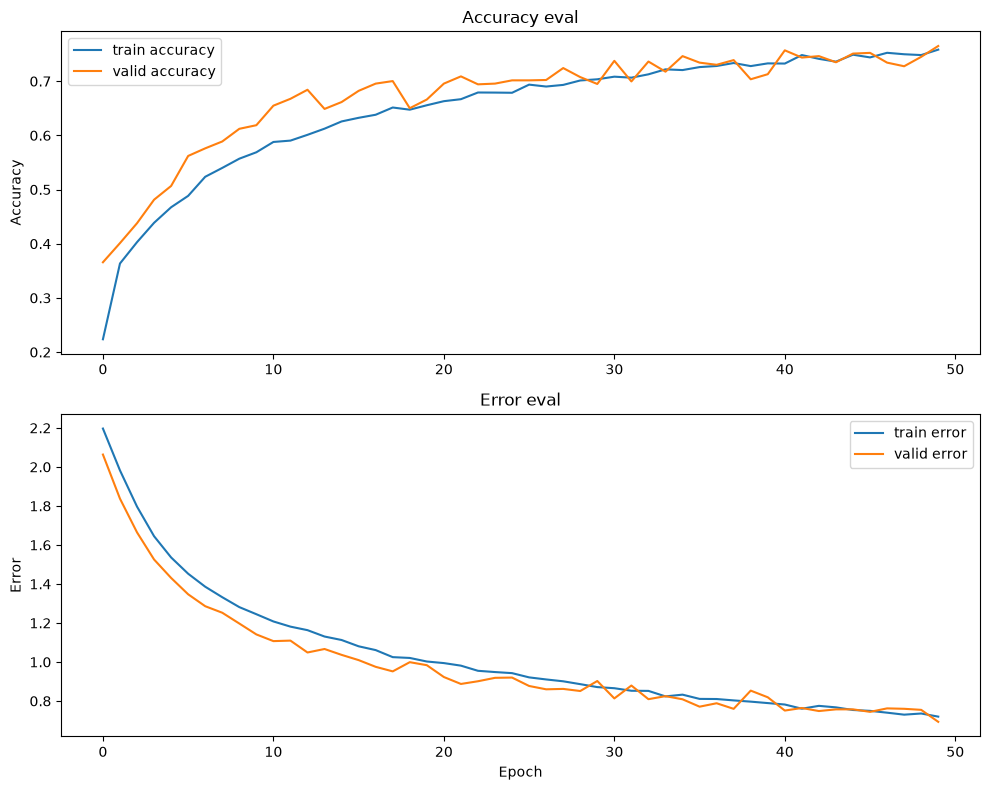

In [8]:
# plot accuracy and error over the epochs
plot_history(model_history)

### Evaluation Loss


In [9]:
test_loss, test_acc = evaluate(model, test_dataloader, loss_fn, device)
print(f"Final Test Loss: {test_loss:.4f} | Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.7064 | Final Test Accuracy: 0.7597


### Test Inference


In [10]:
def predict(model, X, y, mapping, device=torch.device("cpu")):
    X = X.unsqueeze(0).to(device)
    model.to(device)
    model.eval()

    with torch.inference_mode():
        logits = model(X)
        predicted_class = logits.argmax(1).item()

    target_genre = mapping[y.item()]
    predicted_genre = mapping[predicted_class]
    print(
        f"Prediction: {predicted_class} ({predicted_genre}) | Target: {y.item()} ({target_genre})"
    )

In [11]:
X, y = test_dataset[100]
predict(model, X, y, mapping, device)

Prediction: 4 (hiphop) | Target: 4 (hiphop)
